In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
from scipy.integrate import quad
import seaborn as sns
from scipy import stats


plt.rcParams.update({'font.size': 12})
plt.rcParams['figure.figsize'] = (10, 6)

slope: 1.88, intercept: 5.13


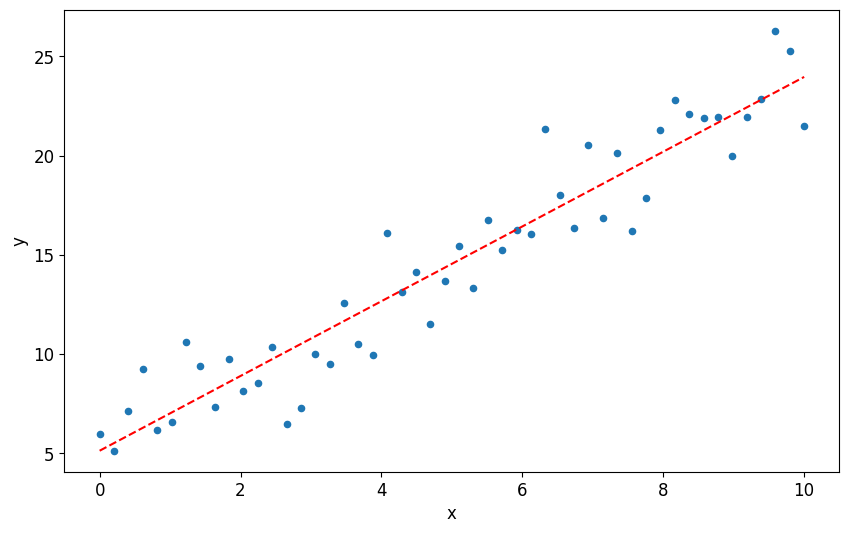

In [ ]:
# Ustawienie seed dla powtarzalności
np.random.seed(42)

# Generowanie danych: y ≈ 2x + 5 + szum
n = 50
x = np.linspace(0, 10, n)
y_true = 2 * x + 5  # prawdziwa zależność
noise = np.random.normal(0, 2, n)  # losowy szum
y = y_true + noise

# Stworzenie DataFrame
data = pd.DataFrame({'x': x, 'y': y})


slope, intercept, r_value, p_value, std_err = stats.linregress(data.x, data.y)
print(f"slope: {slope:.2f}, intercept: {intercept:.2f}")
fig, ax = plt.subplots()
data.plot(kind="scatter", x='x', y='y', ax=ax)
y_linreg = slope*x + intercept
ax.plot(x, y_linreg, 'r--')

In [ ]:
def fit_and_plot(x, y, ax):
  slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
  print(f"slope: {slope:.2f}, intercept: {intercept:.2f}")
  print(f"r: {r_value}")
  print(f"err: {std_err}")
  ax.plot(x, y, 'bo')
  x_linspace = np.linspace(min(x), max(x), 30)
  y_linreg = slope*x_linspace + intercept
  ax.plot(x_linspace, y_linreg, 'r-')

In [ ]:
np.savetxt("dane_do_fit.txt", np.c_[x, y])

In [ ]:
df = pd.read_csv("dane_do_fit.txt", delimiter=" ", header=None, names=["x", "y"])

In [ ]:
df.head()

,x,y
0,0.000000,5.993428
1,0.204082,5.131635
2,0.408163,7.111704
3,0.612245,9.270550
4,0.816327,6.164346


slope: 1.88, intercept: 5.13
r: 0.9503548762459013
err: 0.08903837899142658


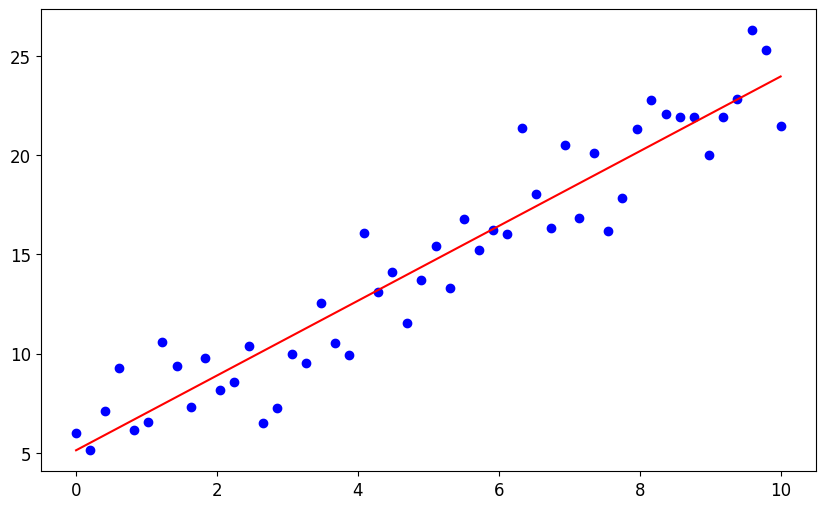

In [ ]:
fig, ax = plt.subplots()
fit_and_plot(df['x'], df['y'], ax)

## Zadanie 1

1. **Wczytaj dane:**
   - Wczytaj dane z pliku `anscombe.csv` do DataFrame za pomocą biblioteki `pandas`.
   - Przekształć dane, aby miały format:

     ```
         x1    y1    x2    y2    x3     y3   x4    y4
     0  10.0  8.04  10.0  9.14  10.0   7.46  8.0  6.58
     1   8.0  6.95   8.0  8.14   8.0   6.77  8.0  5.76
     ```

2. **Stwórz wykresy punktowe:**
   - Użyj biblioteki `matplotlib` lub `seaborn`, aby stworzyć wykresy.
   - Na każdej osi (`ax`) umieść wykres punktowy dla par `x1, y1`, `x2, y2`, `x3, y3` oraz `x4, y4`.





In [ ]:
! head anscombe.csv

0,0,1,1,2,2,3,3
x,y,x,y,x,y,x,y
10.0,8.04,10.0,9.14,10.0,7.46,8.0,6.58
8.0,6.95,8.0,8.14,8.0,6.77,8.0,5.76
13.0,7.58,13.0,8.74,13.0,12.74,8.0,7.71
9.0,8.81,9.0,8.77,9.0,7.11,8.0,8.84
11.0,8.33,11.0,9.26,11.0,7.81,8.0,8.47
14.0,9.96,14.0,8.10,14.0,8.84,8.0,7.04
6.0,7.24,6.0,6.13,6.0,6.08,8.0,5.25
4.0,4.26,4.0,3.10,4.0,5.39,19.0,12.50


     x1    y1    x2    y2    x3    y3   x4    y4
0  10.0  8.04  10.0  9.14  10.0  7.46  8.0  6.58
1   8.0  6.95   8.0  8.14   8.0  6.77  8.0  5.76


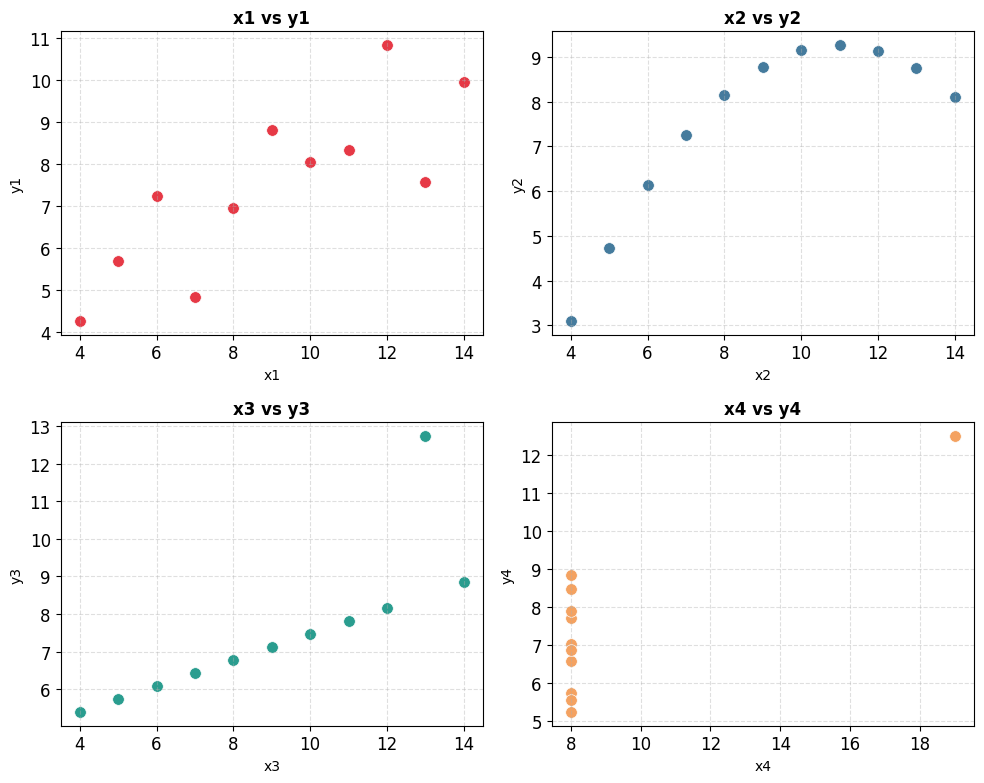

In [3]:
raw = pd.read_csv("anscombe.csv", header=None)

columns = ["x1", "y1", "x2", "y2", "x3", "y3", "x4", "y4"]
df = raw.iloc[2:].reset_index(drop=True)
df.columns = columns
df = df.astype(float)

print(df.head(2).to_string())

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
pairs = [("x1", "y1"), ("x2", "y2"), ("x3", "y3"), ("x4", "y4")]
colors = ["#E63946", "#457B9D", "#2A9D8F", "#F4A261"]

for ax, (x, y), color in zip(axes.flat, pairs, colors):
    ax.scatter(df[x], df[y], color=color, s=70, edgecolors="white", linewidths=0.5)
    ax.set_title(f"{x} vs {y}", fontsize=12, fontweight="bold")
    ax.set_xlabel(x, fontsize=10)
    ax.set_ylabel(y, fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

## Zadanie 2

Przeprowadź eksploracyjną analizę danych (EDA) dla zbioru danych o domach `house_train.csv`

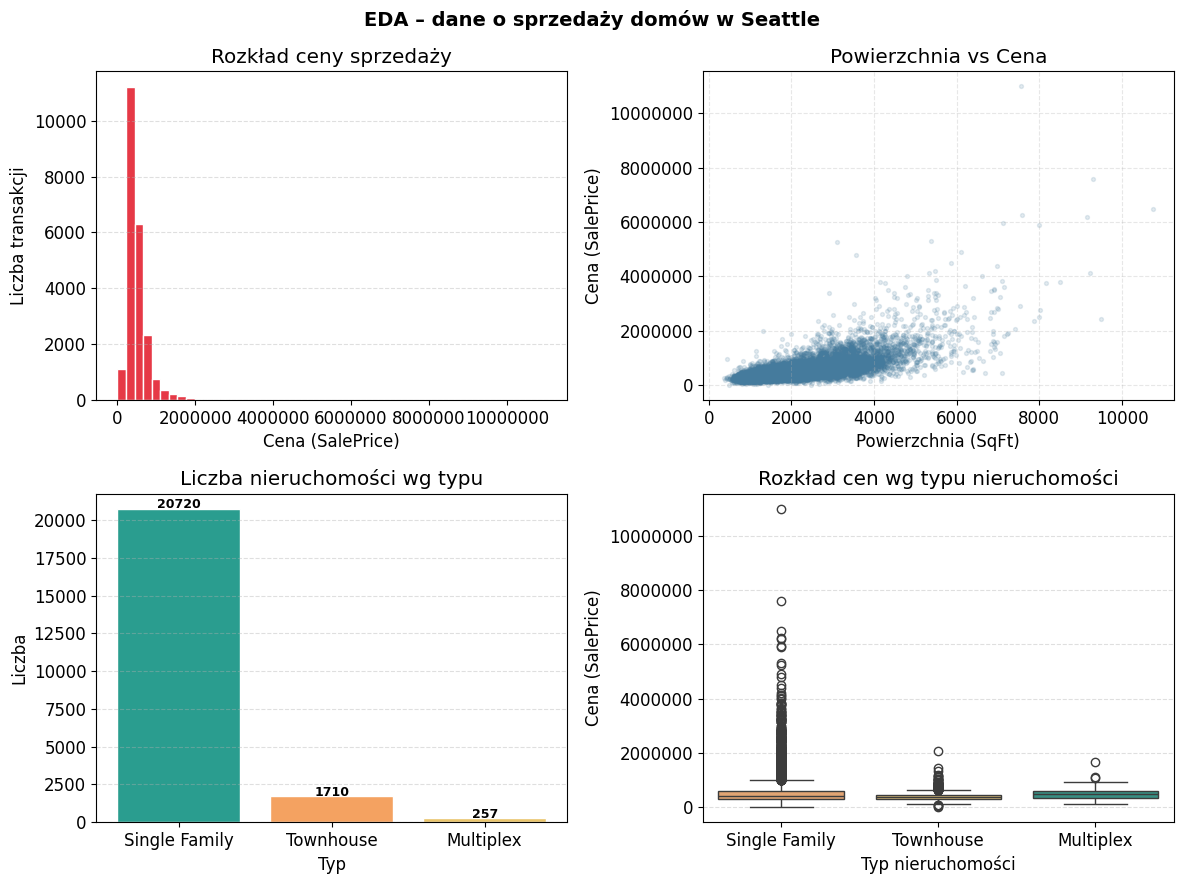

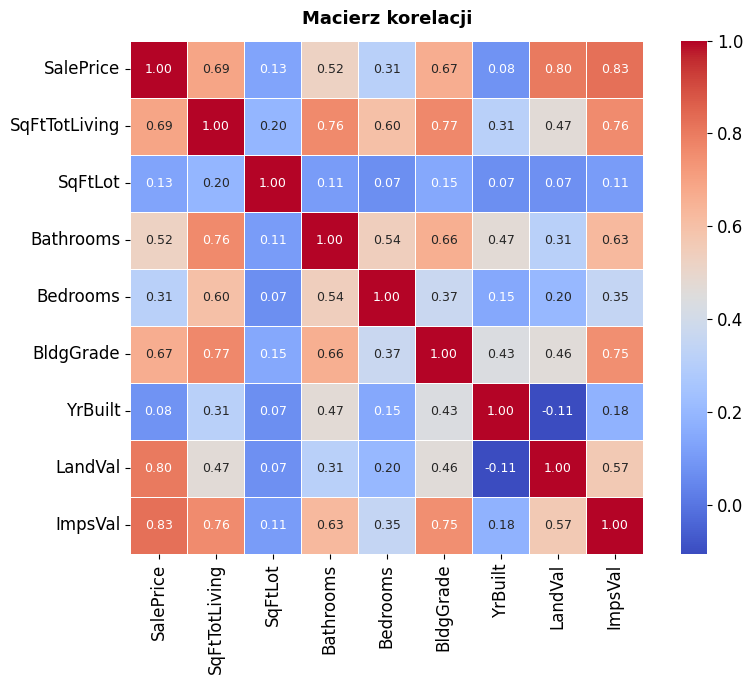

In [8]:
df = pd.read_csv("house_sales.csv", sep="\t")
df["DocumentDate"] = pd.to_datetime(df["DocumentDate"])
df["Year"] = df["DocumentDate"].dt.year

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle("EDA – dane o sprzedaży domów w Seattle", fontsize=14, fontweight="bold")

ax = axes[0, 0]
ax.hist(df["SalePrice"], bins=50, color="#E63946", edgecolor="white")
ax.set_title("Rozkład ceny sprzedaży")
ax.set_xlabel("Cena (SalePrice)")
ax.set_ylabel("Liczba transakcji")
ax.ticklabel_format(style="plain", axis="x")
ax.grid(axis="y", linestyle="--", alpha=0.4)

ax = axes[0, 1]
ax.scatter(df["SqFtTotLiving"], df["SalePrice"], alpha=0.15, s=8, color="#457B9D")
ax.set_title("Powierzchnia vs Cena")
ax.set_xlabel("Powierzchnia (SqFt)")
ax.set_ylabel("Cena (SalePrice)")
ax.ticklabel_format(style="plain", axis="y")
ax.grid(linestyle="--", alpha=0.3)

ax = axes[1, 0]
counts = df["PropertyType"].value_counts()
ax.bar(counts.index, counts.values, color=["#2A9D8F", "#F4A261", "#E9C46A"], edgecolor="white")
for i, v in enumerate(counts.values):
    ax.text(i, v + 50, str(v), ha="center", fontsize=9, fontweight="bold")
ax.set_title("Liczba nieruchomości wg typu")
ax.set_xlabel("Typ")
ax.set_ylabel("Liczba")
ax.grid(axis="y", linestyle="--", alpha=0.4)

ax = axes[1, 1]
order = df["PropertyType"].value_counts().index.tolist()
sns.boxplot(data=df, x="PropertyType", y="SalePrice", order=order,
            hue="PropertyType", palette=["#2A9D8F", "#F4A261", "#E9C46A"],
            legend=False, ax=ax)
ax.set_title("Rozkład cen wg typu nieruchomości")
ax.set_xlabel("Typ nieruchomości")
ax.set_ylabel("Cena (SalePrice)")
ax.ticklabel_format(style="plain", axis="y")
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

num_cols = ["SalePrice", "SqFtTotLiving", "SqFtLot", "Bathrooms",
            "Bedrooms", "BldgGrade", "YrBuilt", "LandVal", "ImpsVal"]
corr = df[num_cols].corr()

fig2, ax2 = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            square=True, linewidths=0.5, ax=ax2, annot_kws={"size": 9})
ax2.set_title("Macierz korelacji", fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()